### Installing Required Libraries

This cell installs all the Python libraries needed for this project.  
These include libraries for deep learning (PyTorch), transformers (Hugging Face), datasets, and machine learning evaluation.  
Installing them ensures the notebook can run correctly in Google Colab or Jupyter


In [3]:
!pip install datasets transformers scikit-learn torch

### Importing Python Libraries

This cell imports all the required libraries used throughout the notebook.  
These libraries help with data loading, model training, evaluation, and visualisation.  
Importing everything at the beginning keeps the workflow organised and reproducible.

In [4]:
# Core libraries for numerical computation and data handling
import numpy as np
import pandas as pd

# PyTorch is used as the backend deep learning framework for model training
import torch

# Hugging Face Transformers provides pre-trained BERT models and tokenizers
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer

# Hugging Face Datasets is used to load and manage the AG News dataset efficiently
from datasets import load_dataset

# Scikit-learn metrics are used for evaluating model performance
# (accuracy, precision, recall, and F1-score)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: Tesla T4


### Loading the Dataset

This cell loads the AG News dataset using the Hugging Face `datasets` library.  
The dataset contains news articles classified into four categories: World, Sports, Business, and Sci/Tech.  
It is automatically split into training and testing sets.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("ag_news")
dataset



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

# Dataset Exploration and Analysis

An exploratory analysis of the AG News dataset shows that the data is evenly distributed across four classes: World, Sports, Business, and Sci/Tech. The majority of news articles contain fewer than 128 tokens, which motivated the choice of maximum sequence length during tokenization to balance information retention and computational efficiency.

In [ ]:
print(dataset)
print("\nDataset splits:", dataset.keys())

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Dataset splits: dict_keys(['train', 'test'])


In [ ]:
def show_samples(dataset, n=5):
    for i in range(n):
        print(f"\nExample {i+1}")
        print("Label:", dataset["train"][i]["label"])
        print("Text:", dataset["train"][i]["text"][:300], "...")


In [ ]:
show_samples(dataset)



Example 1
Label: 2
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. ...

Example 2
Label: 2
Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market. ...

Example 3
Label: 2
Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. ...

Example 4
Label: 2
Text: Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official 

/tmp/ipython-input-1581853849.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=label_names, y=label_counts.values, palette="pastel")


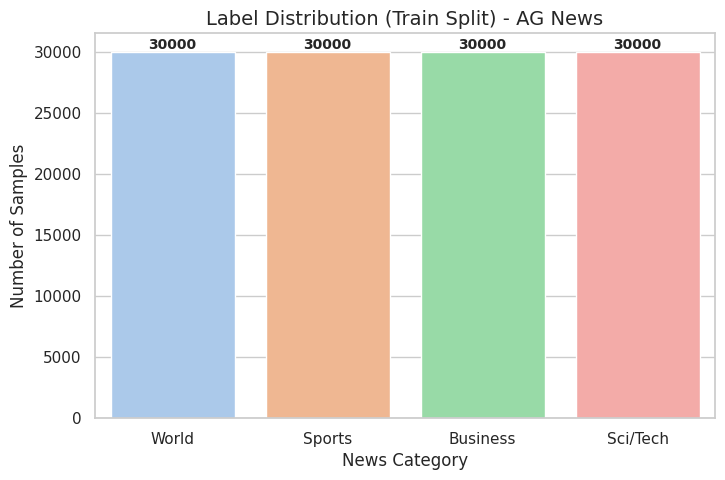

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Function to plot label distribution

def plot_label_distribution(dataset, split="train", label_column="label", figsize=(8,5)):
    """
    Plots the distribution of class labels in a dataset split.

    Parameters:
    - dataset: HuggingFace DatasetDict
    - split: Dataset split to analyze ('train', 'test', etc.)
    - label_column: Column containing labels
    - figsize: Size of the figure

    Returns:
    - None (displays the plot)
    """
    labels = dataset[split][label_column]
    label_counts = pd.Series(labels).value_counts().sort_index()

    # Optional: update label names if known
    label_names = ["World", "Sports", "Business", "Sci/Tech"]

    # Seaborn styling
    sns.set(style="whitegrid")

    plt.figure(figsize=figsize)
    bars = sns.barplot(x=label_names, y=label_counts.values, palette="pastel")

    # Add value annotations on top of bars
    for bar, count in zip(bars.patches, label_counts.values):
        bars.annotate(f'{count}', (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                      ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.xlabel("News Category", fontsize=12)
    plt.ylabel("Number of Samples", fontsize=12)
    plt.title(f"Label Distribution ({split.capitalize()} Split) - AG News", fontsize=14)
    plt.show()


# Example usage

plot_label_distribution(dataset)


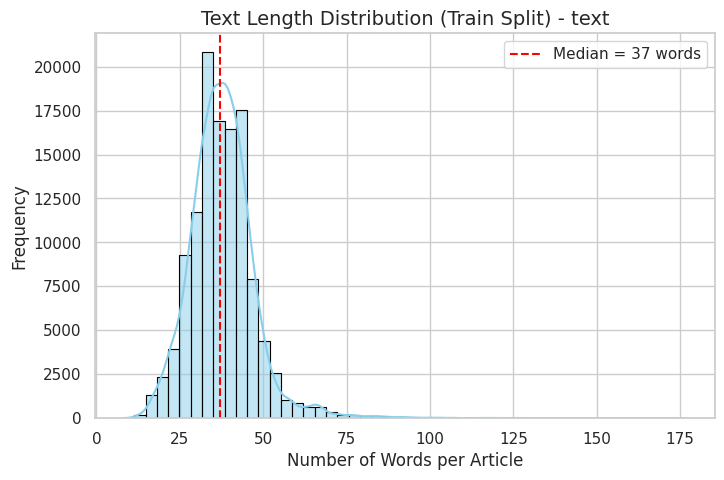

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot text length distribution

def plot_text_length_distribution(dataset, split="train", column="text", bins=50, figsize=(8,5)):
    """
    Plots the distribution of text lengths (number of words) in a dataset split.

    Parameters:
    - dataset: HuggingFace DatasetDict
    - split: Dataset split to analyze ('train', 'test', etc.)
    - column: Column name containing text
    - bins: Number of bins for the histogram
    - figsize: Figure size

    Returns:
    - None (displays the plot)
    """
    # Calculate text lengths
    text_lengths = [len(text.split()) for text in dataset[split][column]]

    # Set seaborn style
    sns.set(style="whitegrid")

    # Create figure
    plt.figure(figsize=figsize)

    # Plot histogram with KDE
    sns.histplot(text_lengths, bins=bins, kde=True, color="skyblue", edgecolor="black")

    # Labels and title
    plt.xlabel("Number of Words per Article", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.title(f"Text Length Distribution ({split.capitalize()} Split) - {column}", fontsize=14)

    # Show median line
    median_len = int(np.median(text_lengths))
    plt.axvline(median_len, color="red", linestyle="--", label=f"Median = {median_len} words")
    plt.legend()

    plt.show()


# Example usage

plot_text_length_distribution(dataset)


# Methodology (Tokenisation & Preprocessing)

This cell implements the preprocessing and tokenisation stage of the methodology.
The bert-base-uncased tokenizer is used to convert raw news articles into token IDs that BERT can process.
Truncation and padding are applied to ensure consistent sequence length, which is set to 128 tokens based on prior EDA of article lengths.
The function is reusable for both training and test splits.
After tokenisation, the dataset is formatted as a PyTorch-ready dataset, keeping only the necessary columns (input_ids, attention_mask, labels) to support model fine-tuning and reproducibility.

In [ ]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def preprocess_dataset(dataset, tokenizer, max_len=128):
    """
    Tokenises AG News articles for BERT input.
    """

    def tokenize(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=max_len
        )

    tokenized = dataset.map(tokenize, batched=True)
    tokenized = tokenized.rename_column("label", "labels")
    tokenized.set_format(
        "torch",
        columns=["input_ids", "attention_mask", "labels"]
    )

    return tokenized


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
tokenized_dataset = preprocess_dataset(dataset, tokenizer)
tokenized_dataset


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7600
    })
})

**Methodology (Metric Definition for Model Evaluation)**

This cell defines the evaluation metrics used to assess model performance during training and testing.
The function compute_metrics takes predicted logits and true labels as input, converts logits to predicted class labels, and calculates key performance metrics:

Accuracy: overall correctness of predictions

Precision, Recall, F1-Score: weighted metrics to account for all four classes, providing detailed performance information across categories
These metrics will be automatically computed by the Hugging Face Trainer during model fine-tuning and evaluation, ensuring consistent and reproducible performance reporting.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )
    accuracy = accuracy_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


**Methodology (Fine-Tuning BERT for News Classification)**

This cell defines a reusable function to initialise and fine-tune a pre-trained BERT model for multi-class news classification.

The model’s classification head is adapted to predict four categories corresponding to AG News labels.

Training is performed using the Hugging Face Trainer API with a learning rate of 2e-5, batch size of 16, and three epochs.

The function accepts training and evaluation datasets, and uses the previously defined compute_metrics function to report accuracy, precision, recall, and F1-score after each evaluation step.

Returning the Trainer object allows further evaluation, predictions, and access to training logs for analysis.
This setup ensures reproducible fine-tuning of BERT for the news classification task.

In [ ]:
def train_bert_classifier(train_ds, eval_ds):
    """
    Initialise and fine-tune BERT for news topic classification.
    """

    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=4
    )

    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )

    trainer.train()
    return trainer


This cell runs the train_bert_classifier function on the training and test datasets, initiating BERT fine-tuning for the AG News classification task.
The resulting trainer object contains the trained model, evaluation metrics, and logs for further analysis.

In [ ]:
trainer = train_bert_classifier(
    tokenized_dataset["train"],
    tokenized_dataset["test"]
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4264915687.py:22: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.194500,0.177888,0.944342,0.944679,0.944342,0.944376
2,0.129700,0.190955,0.946711,0.946808,0.946711,0.946733
3,0.076400,0.232084,0.947237,0.947514,0.947237,0.947271


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def bert_classification_report(trainer, dataset, class_names=None):
    """
    Generates a classification report for BERT predictions.

    Parameters:
    - trainer: HuggingFace Trainer object (already trained)
    - dataset: tokenized dataset to evaluate on (e.g., tokenized_dataset['test'])
    - class_names: optional list of class names for the report

    Returns:
    - report: dictionary of metrics
    """
    # Get predictions
    predictions = trainer.predict(dataset)
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids

    # Default class names if not provided
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y_true)))]

    # Generate classification report
    report = classification_report(
        y_true, y_pred, target_names=class_names, digits=4
    )

    print("=== Classification Report ===")
    print(report)

    return report

# Example usage
class_names = ["World", "Sports", "Business", "Sci/Tech"]
bert_report = bert_classification_report(trainer, tokenized_dataset["test"], class_names=class_names)


=== Classification Report ===
              precision    recall  f1-score   support

       World     0.9629    0.9553    0.9590      1900
      Sports     0.9895    0.9874    0.9884      1900
    Business     0.9293    0.9068    0.9180      1900
    Sci/Tech     0.9084    0.9395    0.9237      1900

    accuracy                         0.9472      7600
   macro avg     0.9475    0.9472    0.9473      7600
weighted avg     0.9475    0.9472    0.9473      7600



# Evaluation & Visualisation

This section evaluates the performance of the fine-tuned BERT model after training. It visualises the training progress by plotting the training loss trend alongside validation accuracy across epochs, which helps assess model convergence and stability. In addition, a confusion matrix is generated using predictions on the test set to analyse class-wise performance and identify common misclassifications. These visualisations support interpretation of the model’s results and ensure the training process and final performance are clearly understood and reproducible.

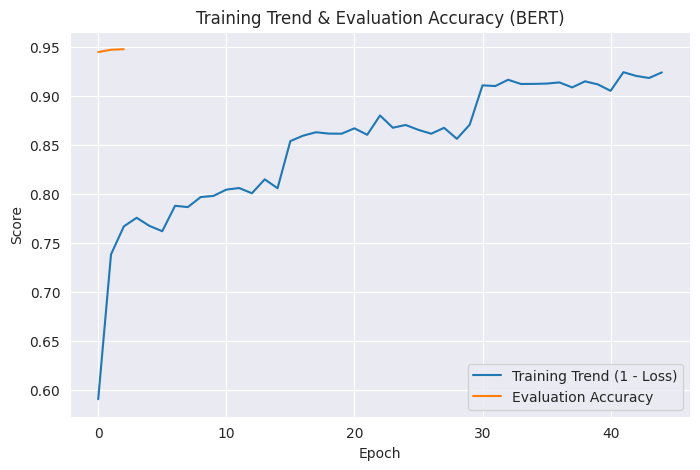

Final Test Accuracy: 0.9472


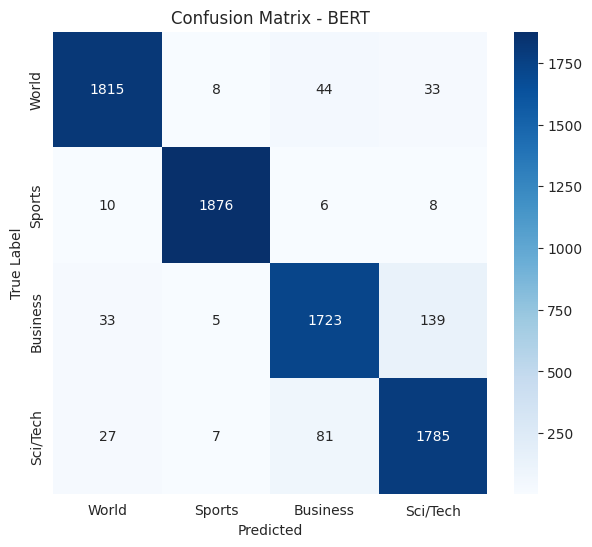

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score


# Function to plot training trends

def plot_training_accuracy(trainer):
    """
    Plots training trend and evaluation accuracy from HuggingFace Trainer logs.
    Training trend uses 1 - loss as a proxy for visualisation.
    """
    train_trend = []
    eval_acc = []

    for log in trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            train_trend.append(1 - log["loss"])  # pseudo-accuracy to visualize loss trend
        if "eval_accuracy" in log:
            eval_acc.append(log["eval_accuracy"])

    plt.figure(figsize=(8,5))
    plt.plot(train_trend, label="Training Trend (1 - Loss)")
    plt.plot(eval_acc, label="Evaluation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Training Trend & Evaluation Accuracy (BERT)")
    plt.legend()
    plt.grid(True)
    plt.show()


# Function to plot confusion matrix

def plot_confusion_matrix(trainer, dataset, class_names=None, cmap="Blues"):
    """
    Computes predictions using the trainer and plots a confusion matrix.

    Parameters:
    - trainer: HuggingFace Trainer object
    - dataset: dataset to evaluate on (e.g., tokenized_dataset['test'])
    - class_names: list of class names to display on axes
    - cmap: color map for heatmap
    """
    predictions = trainer.predict(dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    # Print overall accuracy
    acc = accuracy_score(labels, preds)
    print(f"Final Test Accuracy: {acc:.4f}")

    # Default class names if not provided
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(labels)))]

    # Plot confusion matrix as heatmap
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - BERT")
    plt.xlabel("Predicted")
    plt.ylabel("True Label")
    plt.show()


# Function calls

plot_training_accuracy(trainer)
plot_confusion_matrix(trainer, tokenized_dataset["test"], class_names=["World", "Sports", "Business", "Sci/Tech"])


# Baseline Model

In this part of the notebook, I implement a baseline text classification model using TF-IDF and Logistic Regression. I use the TF-IDF vectorizer to convert the raw news text into numerical features that capture the importance of words in each article. These features are then fed into a Logistic Regression classifier, which learns to predict the correct news category based on the training data. By using a pipeline, I combine vectorization and classification into a single, reusable workflow that I can apply to both training and test data. After training, I evaluate the model on the test set by calculating accuracy, precision, recall, and F1-score, which help me understand how well the model performs. Finally, I generate a classification report to show these metrics for each news category, allowing me to compare this baseline performance to the fine-tuned BERT model.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
from sklearn.pipeline import Pipeline


# Function to train baseline model

def train_baseline_tfidf_lr(train_texts, train_labels, max_features=20000, C=1.0, max_iter=2000):
    """
    Trains a baseline Logistic Regression model using TF-IDF features.

    Parameters:
    - train_texts: list of training text documents
    - train_labels: list of corresponding labels
    - max_features: maximum number of TF-IDF features
    - C: inverse regularization strength for Logistic Regression
    - max_iter: maximum iterations for convergence

    Returns:
    - baseline_model: trained sklearn pipeline
    """
    # Create a pipeline combining TF-IDF vectorizer and Logistic Regression
    baseline_model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=max_features)),
        ("clf", LogisticRegression(C=C, max_iter=max_iter))
    ])

    # Fit model on training data
    baseline_model.fit(train_texts, train_labels)

    return baseline_model


# Function to evaluate baseline model

def evaluate_baseline_model(model, test_texts, test_labels, class_names=None):
    """
    Generates predictions and prints a classification report.

    Parameters:
    - model: trained sklearn pipeline
    - test_texts: list of test documents
    - test_labels: true labels for test documents
    - class_names: optional list of class names for report

    Returns:
    - report: dictionary of metrics (precision, recall, f1, accuracy)
    """
    # Predict on test data
    preds = model.predict(test_texts)

    # Print classification report
    report_str = classification_report(test_labels, preds, target_names=class_names, digits=4)
    print("=== Baseline Classification Report ===")
    print(report_str)

    # Compute overall metrics
    precision, recall, f1, _ = precision_recall_fscore_support(test_labels, preds, average="weighted")
    accuracy = accuracy_score(test_labels, preds)

    report = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    return report


# Example usage

train_texts = dataset["train"]["text"]
train_labels = dataset["train"]["label"]
test_texts = dataset["test"]["text"]
test_labels = dataset["test"]["label"]
class_names = ["World", "Sports", "Business", "Sci/Tech"]

# Train the baseline model
baseline_model = train_baseline_tfidf_lr(train_texts, train_labels)

# Evaluate the baseline model
baseline_metrics = evaluate_baseline_model(baseline_model, test_texts, test_labels, class_names=class_names)


=== Baseline Classification Report ===
              precision    recall  f1-score   support

       World     0.9334    0.9074    0.9202      1900
      Sports     0.9569    0.9805    0.9685      1900
    Business     0.8878    0.8826    0.8852      1900
    Sci/Tech     0.8946    0.9026    0.8986      1900

    accuracy                         0.9183      7600
   macro avg     0.9182    0.9183    0.9181      7600
weighted avg     0.9182    0.9183    0.9181      7600



In this cell, I visualize the performance of the baseline TF-IDF + Logistic Regression model using a confusion matrix. The confusion matrix shows how many news articles from each true category were correctly or incorrectly predicted by the model. I use a heatmap to make it easier to see patterns of misclassification, with the actual labels on the y-axis and the predicted labels on the x-axis. This visualization helps me understand which categories the model struggles with and provides a more detailed evaluation than overall accuracy alone.

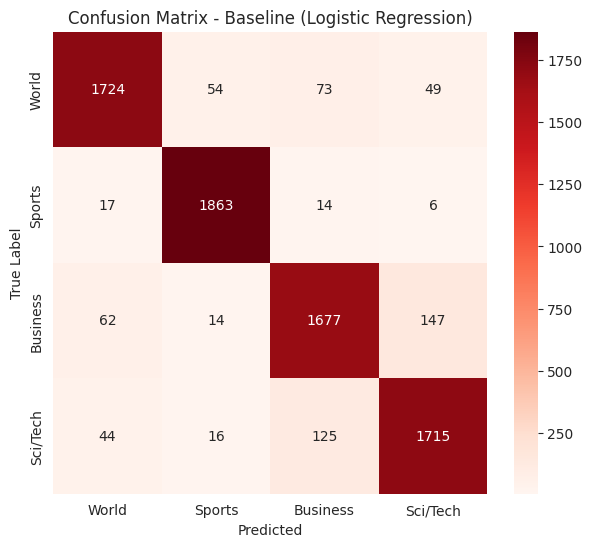

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Function to plot confusion matrix

def plot_confusion_matrix_baseline(true_labels, pred_labels, class_names=None, cmap="Reds", figsize=(7,6)):
    """
    Plots a confusion matrix for the baseline model predictions.

    Parameters:
    - true_labels: ground-truth labels
    - pred_labels: predicted labels from the model
    - class_names: list of class names for axes labels
    - cmap: color map for the heatmap
    - figsize: size of the plot

    Returns:
    - None (displays the confusion matrix plot)
    """
    # Compute confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)

    # Default class names if not provided
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(true_labels)))]

    # Plot confusion matrix as heatmap
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - Baseline (Logistic Regression)")
    plt.xlabel("Predicted")
    plt.ylabel("True Label")
    plt.show()


# Example usage

labels_names = ["World", "Sports", "Business", "Sci/Tech"]

# Generate predictions using the trained baseline_model
baseline_preds = baseline_model.predict(test_texts)

plot_confusion_matrix_baseline(test_labels, baseline_preds, class_names=labels_names)

In this cell, I compare the overall accuracy of the baseline TF-IDF + Logistic Regression model with the fine-tuned BERT model. I create a bar chart to visually show the difference in performance between the two models. The height of each bar represents the accuracy score, and the values are also displayed above the bars for clarity. This comparison helps me quickly see which model performs better on the AG News classification task and gives a clear summary of the improvement achieved by fine-tuning BERT over the baseline.

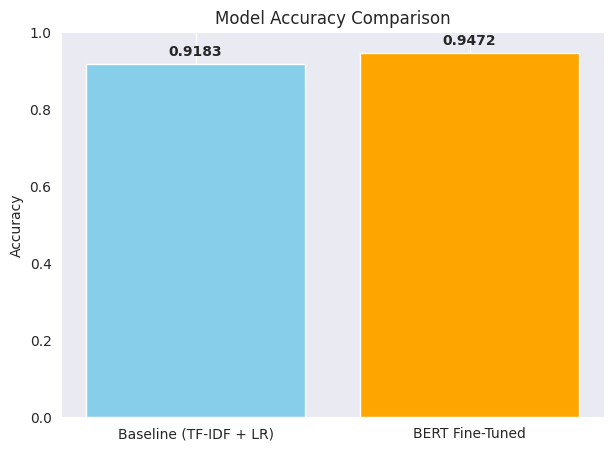

Baseline Accuracy: 0.9182894736842105
BERT Accuracy: 0.9472368421052632


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Function to compare model accuracies

def plot_model_accuracy_comparison(model_names, accuracies, figsize=(7,5)):
    """
    Plots a bar chart comparing accuracies of multiple models.

    Parameters:
    - model_names: list of model names (strings)
    - accuracies: list of accuracy scores corresponding to the models
    - figsize: tuple to set figure size

    Returns:
    - None (displays a bar chart)
    """
    plt.figure(figsize=figsize)
    plt.bar(model_names, accuracies, color=['skyblue', 'orange'])
    plt.ylim(0, 1)
    plt.ylabel("Accuracy")
    plt.title("Model Accuracy Comparison")
    plt.grid(axis='y')

    # Add accuracy values above each bar
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.02, f"{acc:.4f}", ha='center', fontweight='bold')

    plt.show()

# Example usage

bert_accuracy = eval_acc[-1]
baseline_accuracy = accuracy_score(test_labels, baseline_preds)

model_names = ["Baseline (TF-IDF + LR)", "BERT Fine-Tuned"]
accuracies = [baseline_accuracy, bert_accuracy]

plot_model_accuracy_comparison(model_names, accuracies)

#  print accuracy values
print("Baseline Accuracy:", baseline_accuracy)
print("BERT Accuracy:", bert_accuracy)


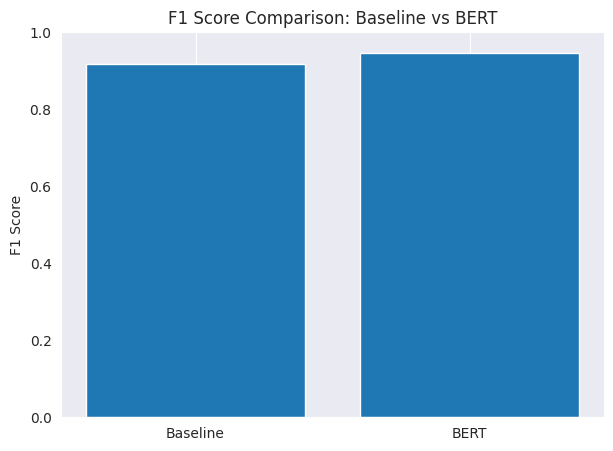

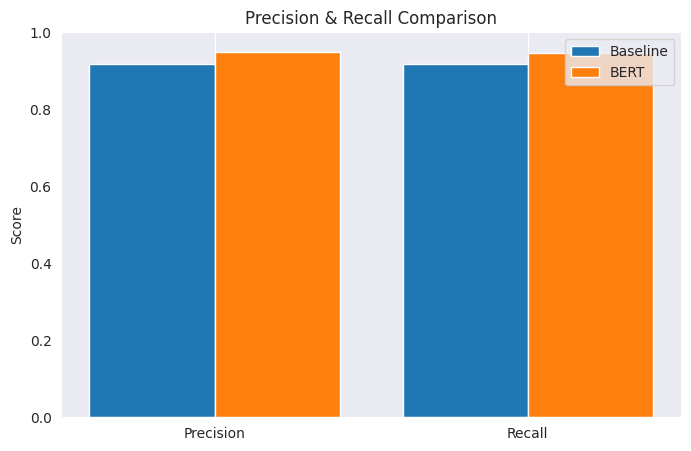


=== PERFORMANCE SUMMARY TABLE ===

                    Model  Accuracy  Precision    Recall  F1 Score
0  Baseline (TF-IDF + LR)  0.918289   0.918165  0.918289  0.918139
1         BERT Fine-Tuned  0.947237   0.947514  0.947237  0.947271


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# Function to calculate metrics for any model

def calculate_classification_metrics(y_true, y_pred):
    """
    Computes weighted precision, recall, F1-score, and accuracy for multi-class classification.

    Parameters:
    - y_true: Ground-truth labels
    - y_pred: Predicted labels

    Returns:
    - metrics: Dictionary with 'accuracy', 'precision', 'recall', 'f1'
    """
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted'
    )
    accuracy = accuracy_score(y_true, y_pred)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


# Function to plot F1, Precision & Recall comparison

def plot_model_metrics_comparison(baseline_metrics, bert_metrics):
    """
    Plots comparison graphs for F1, Precision, and Recall between baseline and BERT models.
    Also creates a summary table.

    Parameters:
    - baseline_metrics: dict of metrics for baseline model
    - bert_metrics: dict of metrics for BERT model

    Returns:
    - summary_df: pandas DataFrame summarizing the metrics
    """
    # F1 Score comparison
    plt.figure(figsize=(7,5))
    plt.bar(["Baseline", "BERT"], [baseline_metrics["f1"], bert_metrics["f1"]])
    plt.ylim(0, 1)
    plt.ylabel("F1 Score")
    plt.title("F1 Score Comparison: Baseline vs BERT")
    plt.grid(axis='y')
    plt.show()

    # Precision & Recall comparison
    metrics_labels = ["Precision", "Recall"]
    baseline_scores = [baseline_metrics["precision"], baseline_metrics["recall"]]
    bert_scores = [bert_metrics["precision"], bert_metrics["recall"]]

    x = range(len(metrics_labels))
    plt.figure(figsize=(8,5))
    plt.bar([i - 0.2 for i in x], baseline_scores, width=0.4, label="Baseline")
    plt.bar([i + 0.2 for i in x], bert_scores, width=0.4, label="BERT")
    plt.xticks(x, metrics_labels)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title("Precision & Recall Comparison")
    plt.legend()
    plt.grid(axis='y')
    plt.show()

    # Summary table
    summary_data = {
        "Model": ["Baseline (TF-IDF + LR)", "BERT Fine-Tuned"],
        "Accuracy": [baseline_metrics["accuracy"], bert_metrics["accuracy"]],
        "Precision": [baseline_metrics["precision"], bert_metrics["precision"]],
        "Recall": [baseline_metrics["recall"], bert_metrics["recall"]],
        "F1 Score": [baseline_metrics["f1"], bert_metrics["f1"]]
    }

    summary_df = pd.DataFrame(summary_data)
    print("\n=== PERFORMANCE SUMMARY TABLE ===\n")
    print(summary_df)
    return summary_df

# Example usage

baseline_metrics = calculate_classification_metrics(test_labels, baseline_preds)

# Get BERT evaluation metrics
bert_eval_results = trainer.evaluate(tokenized_dataset["test"])
bert_metrics = {
    "accuracy": bert_eval_results["eval_accuracy"],
    "precision": bert_eval_results["eval_precision"],
    "recall": bert_eval_results["eval_recall"],
    "f1": bert_eval_results["eval_f1"]
}

summary_df = plot_model_metrics_comparison(baseline_metrics, bert_metrics)
